# Visualize the behavior of the Full & Conjugate Point MCMC chains for Convergence purposes

Loading J0806+2006
samples shape: (3500000, 35) dist length: 3500000
samples shape: (1750000, 35) dist length: 1750000
Combined chain shape: (5250000, 35)
Combined likelihood length: 5250000
Loading J2325-5229
samples shape: (3600000, 36) dist length: 3600000
samples shape: (1800000, 36) dist length: 1800000
Combined chain shape: (5400000, 36)
Combined likelihood length: 5400000


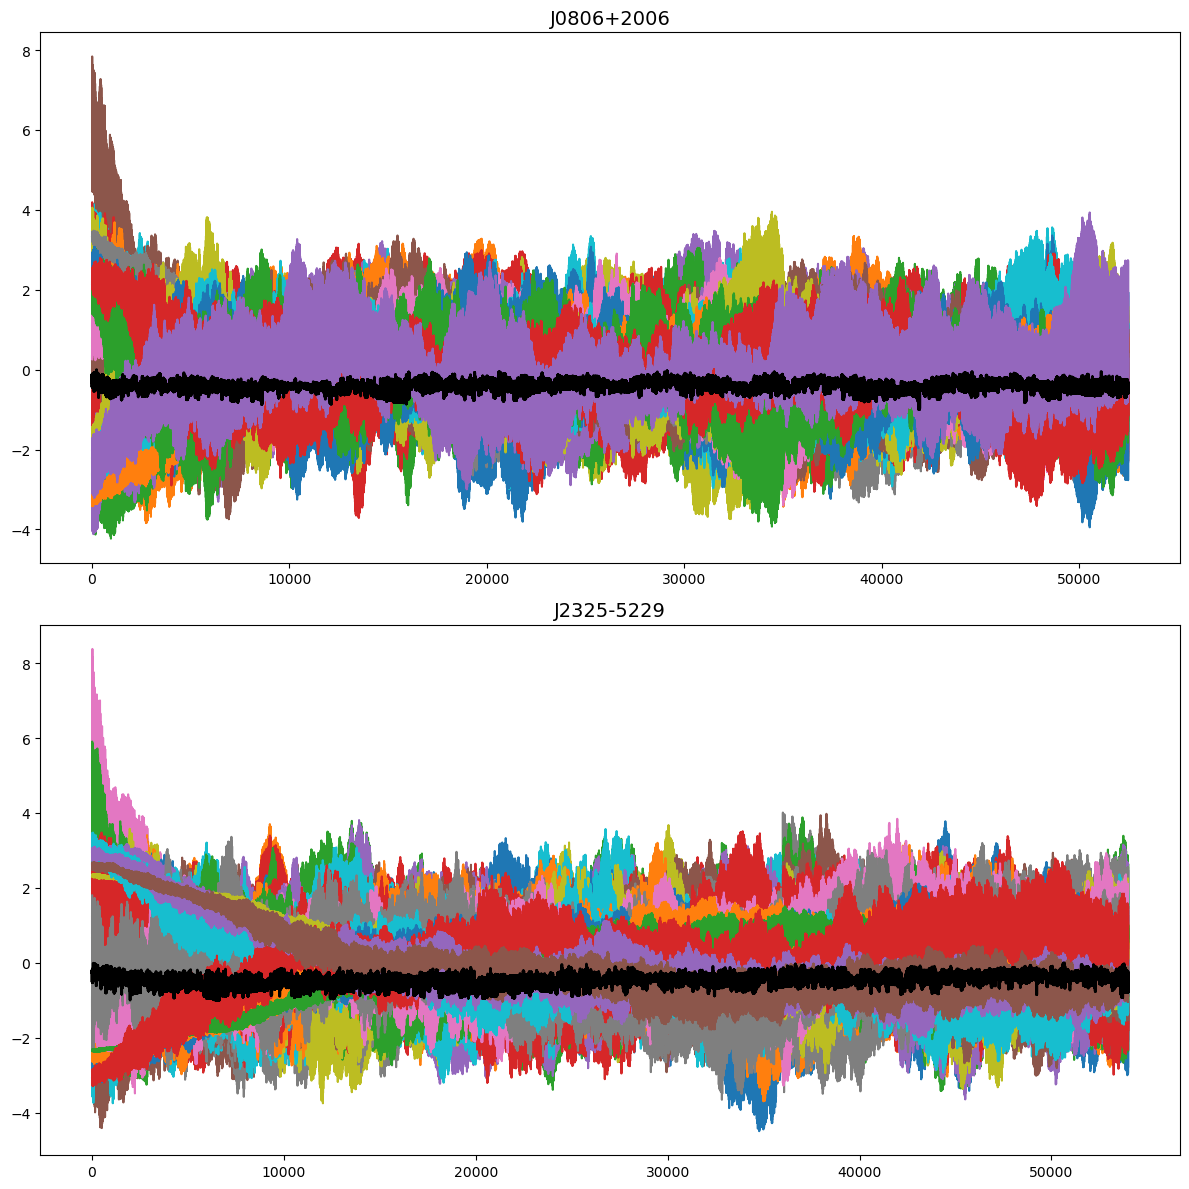

In [1]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
import os
from lenstronomy.Plots import chain_plot


# Lens systems to plot
names = [#'J0407-5006', 
         #'J0602-4335',
         'J0806+2006', 
         #'J1001+5027',
         #'J1442+4055',
         #'J1515+1511',
         #'J1620+1203',
         'J2325-5229'
]

class CustomUnpickler(pickle.Unpickler):
    def find_class(self, module, name):
        if name == "LikelihoodAddition":
            class LikelihoodAddition:
                pass
            return LikelihoodAddition
        return super().find_class(module, name)


fig, axes = plt.subplots(len(names), 1, figsize=(12, 6 * len(names)))

if len(names) == 1:
    axes = [axes]


# Loop over lens systems
for ax, name in zip(axes, names):

    filename = f"../joint_modeling/{name}/{name}_joint.pkl"

    if not os.path.exists(filename):
        print(f"{name}: file not found")
        ax.set_title(f"{name} (file missing)")
        continue

    print(f"Loading {name}")

    with open(filename, "rb") as f:
        loaded_data = CustomUnpickler(f).load()

    chain_list = loaded_data.get("chain_list", [])

    samples_list = []
    dist_list = []
    param_mcmc = None

    # Collect all MCMC runs
    for entry in chain_list:

        sampler_type = entry[0].lower()

        if sampler_type in ["emcee", "mcmc"]:

            sampler_type, samples, param_mcmc, dist_mcmc = entry

            samples_list.append(samples)
            dist_list.append(dist_mcmc)

    if len(samples_list) == 0:
        print(f"{name}: no MCMC chains found")
        ax.set_title(f"{name} (no MCMC)")
        continue

    for s, d in zip(samples_list, dist_list):
        print("samples shape:", s.shape, "dist length:", len(d))

    # Concatenate chains (continuous MCMC)
    samples_combined = np.concatenate(samples_list, axis=0)
    dist_combined = np.concatenate(dist_list, axis=0)


    print("Combined chain shape:", samples_combined.shape)
    print("Combined likelihood length:", len(dist_combined))

    # Plot MCMC behaviour
    chain_plot.plot_mcmc_behaviour(
        ax,
        samples_combined,
        param_mcmc,
        dist_combined
    )

    ax.set_title(name, fontsize=14)


# Final formatting
plt.tight_layout()
#plt.savefig('mcmc.png')
plt.show()